In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# 한글 폰트 설정
plt.rcParams['font.family'] = 'HYGothic-Extra'

In [ ]:
# 1. 데이터 전처리 ..
df = pd.read_csv("한국도로교통공단_가해운전자 연령층별 월별 교통사고 통계_20241231.csv", encoding='cp949')
data = np.array(df.values.tolist())

# 입력 특성: X1=사망자 수 (3열), X2=부상자 수 (7열)
# 목표값: y=사고건 수 (2열)
X = data[:, [3, 7]].astype(int)
y = data[:, 2].astype(int)

print("✓ 데이터 전처리 완료")
print(f"  입력 데이터 X 형태: {X.shape}")
print(f"  목표값 y 형태: {y.shape}")

✓ 데이터 전처리 완료
  입력 데이터 X 형태: (96, 2)
  목표값 y 형태: (96,)


In [4]:
# 2. 선형회귀 모델 학습
model = LinearRegression()
model.fit(X, y)

print(f"✓ 모델 학습 완료")
print(f"  회귀식: y = {model.coef_[0]:.4f}*X1 + {model.coef_[1]:.4f}*X2 + {model.intercept_:.4f}")

# 3. 새로운 데이터에 대한 예측
new_data = np.array([[30, 3000]])  # 사망자 30명, 부상자 3000명일 때
predicted_score = model.predict(new_data)
print(f"✓ 예측 완료: 사고건 수 ≈ {predicted_score[0]:.0f}건")

# 4. 회귀 평면 시각화를 위한 그리드 데이터 생성
x1_range = np.linspace(0, 70, 71)
x2_range = np.linspace(0, 6000, 101)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# 모든 입력 조합에 대해 회귀식으로 y값 계산
y_grid = model.coef_[0] * x1_grid + model.coef_[1] * x2_grid + model.intercept_
print(f"✓ 회귀 평면 계산 완료 (그리드 크기: {y_grid.shape})")

✓ 모델 학습 완료
  회귀식: y = 1.8489*X1 + 0.6789*X2 + 27.3527
✓ 예측 완료: 사고건 수 ≈ 2120건
✓ 회귀 평면 계산 완료 (그리드 크기: (101, 71))


findfont: Font family 'HYGothic-Extra' not found.
findfont: Font family 'HYGothic-Extra' not found.
C:\Users\cth62\AppData\Local\Temp\ipykernel_15884\988573242.py:23: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cth62\AppData\Local\Temp\ipykernel_15884\988573242.py:23: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cth62\AppData\Local\Temp\ipykernel_15884\988573242.py:23: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cth62\AppData\Local\Temp\ipykernel_15884\988573242.py:23: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'HYGothic-Extra' not found.
findfont: Font family 'HYGothic-Extra' not found.
C:\Users\cth62\AppData\Local\Temp\ipykernel_15884\988573242.py:23: UserWarning: Glyph 45796 (\N{HANGUL SYLLABL

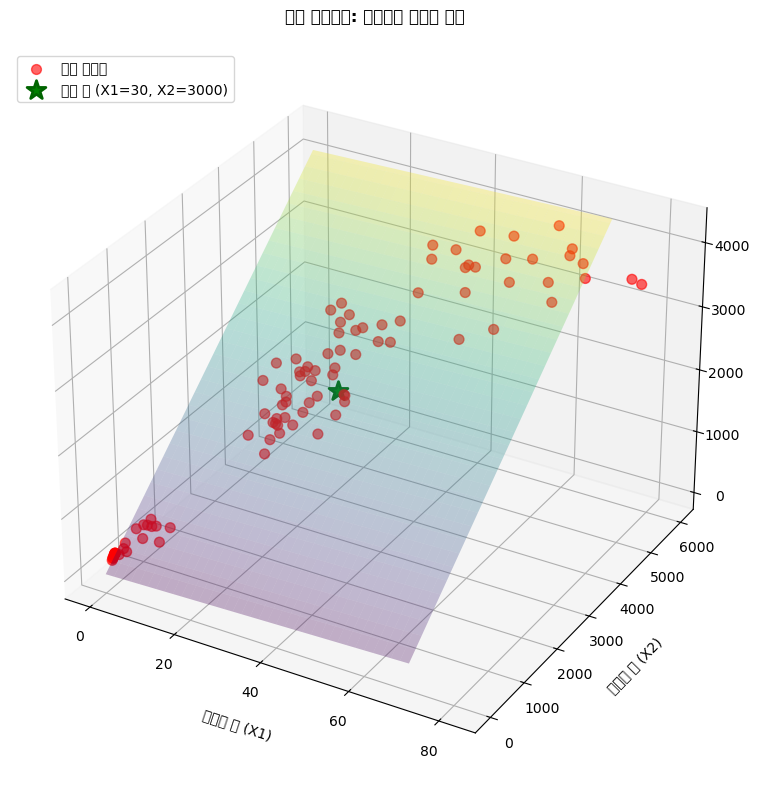

In [ ]:
# 5. 3D 시각화
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 학습 데이터 시각화 (빨강)
ax.scatter(X[:, 0], X[:, 1], y, color='red', s=50, alpha=0.6, label='학습 데이터')

# 예측 점 시각화 (초록)
ax.scatter(new_data[:, 0], new_data[:, 1], predicted_score, color='green', s=200, 
           marker='*', label='예측 점 (X1=30, X2=3000)', edgecolors='darkgreen', linewidth=2)

# 회귀 평면 시각화
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.3)

# 축 레이블 및 제목 (한글)
ax.set_xlabel('사망자 수 (X1)', fontsize=10, labelpad=10)
ax.set_ylabel('부상자 수 (X2)', fontsize=10, labelpad=10)
ax.set_zlabel('사고건 수 (y)', fontsize=10, labelpad=10)
ax.set_title('다중 선형회귀: 교통사고 데이터 분석', fontsize=12, fontweight='bold', pad=20)

# 범례 및 레이아웃
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()